In [1]:
import pandas as pd     # for data manipulation
import matplotlib.pyplot as plt     # for data visualization
import seaborn as sns       # for data visualization
import numpy as np      # for numerical operations
from langdetect import detect, detect_langs   # for language detection


In [2]:
# data loading
df = pd.read_csv('../data/final_labeled_data.csv', encoding='utf-8-sig')
metadata = pd.read_csv('../data/correctedMetadata.csv')

In [3]:
print(df.columns)

Index(['review_text', 'rating', 'word_count', 'is_fake', 'is_duplicate',
       'emojis', 'sentiment', 'scores', 'compound', 'label', 'review_len'],
      dtype='str')


In [4]:
print(metadata.columns)

Index(['Unnamed: 0', 'Wikipedia.Language.Code', 'Language.name..English.',
       'Language.name..native.', 'Last.Updated'],
      dtype='str')


In [5]:
metadata.head()

,Unnamed: 0,Wikipedia.Language.Code,Language.name..English.,Language.name..native.,Last.Updated
0,1,af,Afrikaans,Afrikaans,2014-04-29
1,4,an,Aragonese,Aragonés,2014-04-29
2,5,ar,Arabic,العربية,2014-04-29
3,9,az,Azerbaijani,azərbaycan dili,2014-04-29
4,12,be,Belarusian,Беларуская,2014-04-29


In [6]:
# language detection function with enhanced logic to handle mixed languages and regional variations

def detect_language_smart(text):
    text = str(text).strip()        # Ensure the input is a string and remove leading/trailing whitespace
    if not text or len(text) < 3:   # If the text is empty or too short, we return 'Short/Undefined' to avoid unreliable language detection results.
        return 'Short/Undefined'
    
    try:
        # langdetect can return multiple languages with probabilities, so we check for the top ones
        res = detect_langs(text)
        lang_codes = [l.lang for l in res if l.prob > 0.10]  # Consider languages with >10% confidence
        
        # Mixed & Regional Language Logic
        if 'en' in lang_codes and 'mr' in lang_codes:
            return 'Marathi + English (Mixed)'
        elif 'en' in lang_codes and 'hi' in lang_codes:
            return 'Hindi + English (Mixed)'
        elif 'mr' in lang_codes:
            return 'Marathi'
        elif 'hi' in lang_codes:
            return 'Hindi'
        elif 'en' in lang_codes:
            return 'English'
        else:
            return 'Other/Mixed'
    except:
        return 'English'

print("🔍 Detecting languages, please wait...")
# applies on each review text to detect the language and store it in a new column 
# 'detected_lang' in the DataFrame, allowing us to analyze the distribution of 
# languages in the reviews and potentially filter or segment the data 
# based on language for further analysis or modeling.
df['detected_lang'] = df['review_text'].apply(detect_language_smart)

🔍 Detecting languages, please wait...


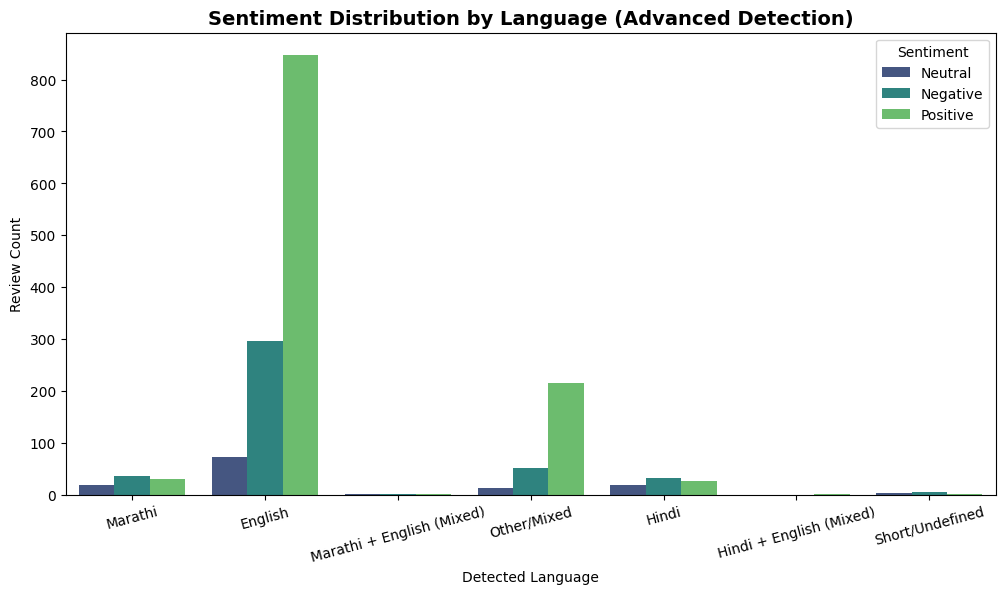

In [7]:
# visualization of language distribution with sentiment breakdown

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='detected_lang', hue='sentiment', palette='viridis')
plt.title('Sentiment Distribution by Language (Advanced Detection)', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.xlabel('Detected Language')
plt.ylabel('Review Count')
plt.legend(title='Sentiment')
plt.show()

In [8]:
# if word_count column doesn't exist, create it by counting the number of words 
# in each review_text entry, which can be useful for analyzing the 
# relationship between review length and sentiment or language.

if 'word_count' not in df.columns:
    df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))

C:\Users\Vaishnavi Giri\AppData\Local\Temp\ipykernel_9932\1990699007.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='detected_lang', y='word_count', data=df, palette='Set3', showfliers=False)


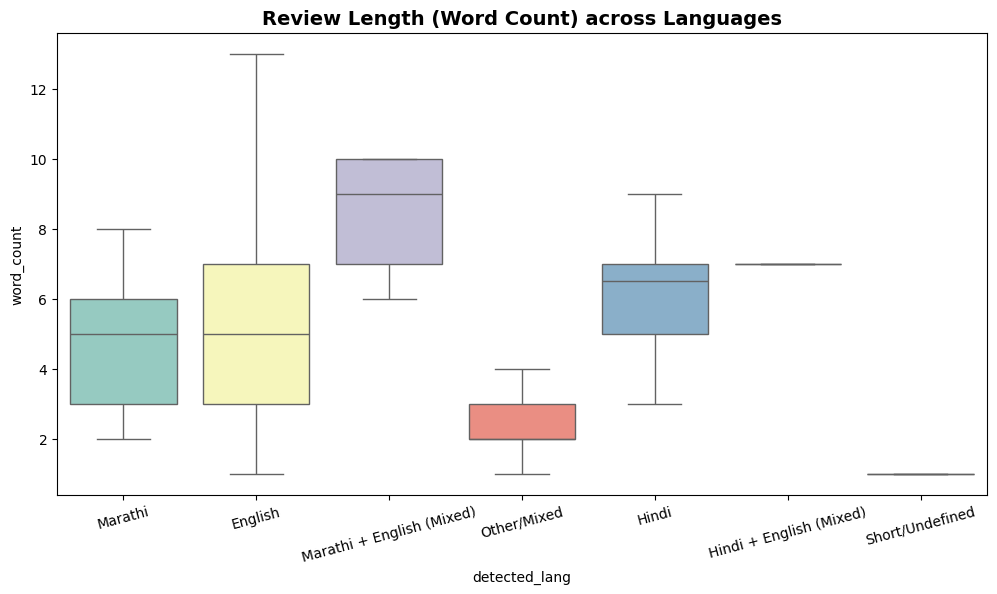

In [9]:
# boxplot to visualize the distribution of review lengths (in terms of word count) 
# across different detected languages, which can help us understand if certain 
# languages tend to have longer or shorter reviews, and how that might relate 
# to sentiment or other factors.

plt.figure(figsize=(12, 6))
sns.boxplot(x='detected_lang', y='word_count', data=df, palette='Set3', showfliers=False)
plt.title('Review Length (Word Count) across Languages', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.show()

C:\Users\Vaishnavi Giri\AppData\Local\Temp\ipykernel_9932\3529596338.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='detected_lang', y='compound', data=df, inner="quart", palette='coolwarm')


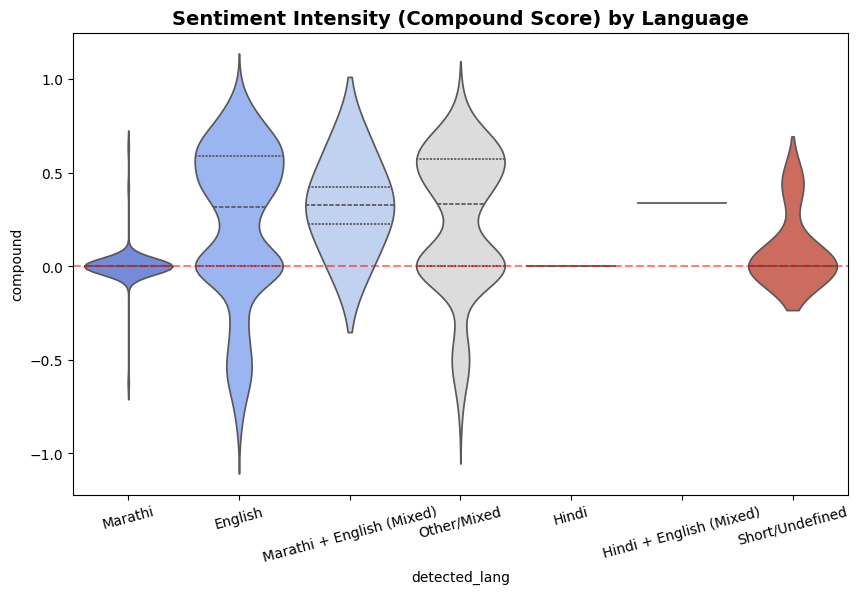

In [10]:
# violin plot to visualize the distribution of sentiment intensity (compound score)
# across different detected languages, which can help us understand if certain
# languages tend to have more positive or negative sentiments, 
# and how the sentiment intensity varies within each language group.

plt.figure(figsize=(10, 6))
sns.violinplot(x='detected_lang', y='compound', data=df, inner="quart", palette='coolwarm')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title('Sentiment Intensity (Compound Score) by Language', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.show()

In [11]:
lang_counts = df['detected_lang'].value_counts()
print("\n--- 📊 Language Distribution Count ---")
print(lang_counts)


--- 📊 Language Distribution Count ---
detected_lang
English                      1217
Other/Mixed                   280
Marathi                        86
Hindi                          78
Short/Undefined                10
Marathi + English (Mixed)       5
Hindi + English (Mixed)         1
Name: count, dtype: int64


In [12]:
# filtering the DataFrame to include only reviews that are 
# detected as Marathi, Hindi, or their mixed forms, allowing us to 
# focus on analyzing the multilingual reviews in more detail.

multilingual_df = df[df['detected_lang'].isin(['Marathi', 'Hindi', 'Marathi + English (Mixed)', 'Hindi + English (Mixed)'])]

print(f"\n--- 📝 Multilingual Reviews Sample (Found: {len(multilingual_df)}) ---")
if not multilingual_df.empty:
    pd.set_option('display.max_colwidth', 100)
    display_sample = pd.concat([multilingual_df.head(5), multilingual_df.tail(5)])
    print(display_sample[['review_text', 'detected_lang', 'sentiment']])
else:
    print("No Marathi or Hindi reviews detected.")


--- 📝 Multilingual Reviews Sample (Found: 170) ---
                                 review_text              detected_lang  \
0            ठीक आहे 🙂 | but थोड़ा expensive                    Marathi   
8                     ठीक आहे 🙂 | looks nice  Marathi + English (Mixed)   
21    पॅकिंग खूप भारी होतं, सुरक्षित मिळालं.                    Marathi   
24              बैटरी बैकअप बहुत कम है इसका।                      Hindi   
34              प्रॉडक्ट अपेक्षेप्रमाणे आहे.                    Marathi   
1655                         पैसे वाया गेले.                    Marathi   
1658   मला हे खूप आवडलं, धन्यवाद फ्लिपकार्ट!                    Marathi   
1662          अच्छी डील है, मैं संतुष्ट हूँ।                      Hindi   
1664                कीमत के हिसाब से ठीक है।                      Hindi   
1673              पैसे वाया गेले, घेऊ नका. 👎                    Marathi   

     sentiment  
0      Neutral  
8     Positive  
21    Positive  
24    Negative  
34     Neutral  
1655  Negative  
165

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'English'),
  Text(1, 0, 'Other/Mixed'),
  Text(2, 0, 'Marathi'),
  Text(3, 0, 'Hindi'),
  Text(4, 0, 'Short/Undefined'),
  Text(5, 0, 'Marathi + English (Mixed)'),
  Text(6, 0, 'Hindi + English (Mixed)')])

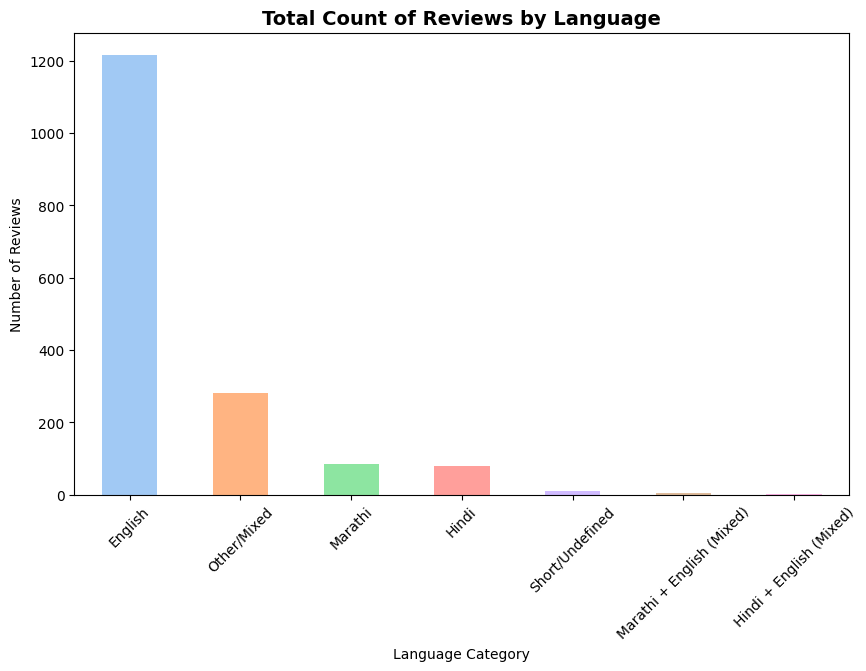

In [13]:
# visualization of the distribution of detected languages in the reviews, 
# which can help us understand the linguistic diversity of the dataset and 
# identify any dominant languages or significant multilingual presence.

plt.figure(figsize=(10, 6))
colors = sns.color_palette('pastel')[0:len(lang_counts)]
lang_counts.plot(kind='bar', color=colors)
plt.title('Total Count of Reviews by Language', fontsize=14, fontweight='bold')
plt.xlabel('Language Category')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)

In [14]:
# final insights export to CSV for further analysis or reporting
df.to_csv('../data/final_insights_multilingual.csv', index=False, encoding='utf-8-sig')
print("\n✅ All Insights Generated Successfully! File saved as 'final_insights_multilingual.csv'")


✅ All Insights Generated Successfully! File saved as 'final_insights_multilingual.csv'
